In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

In [3]:
df = pd.read_csv("../PREPROCESSING/processed_cicids2017.csv")

In [4]:
print(df.shape)
print(df['Label'].value_counts())

(2827876, 48)
Label
0    2271320
1     556556
Name: count, dtype: int64


In [5]:
benign_df = df[df['Label'] == 0]
attack_df = df[df['Label'] == 1]

In [6]:
X_benign = benign_df.drop(columns=['Label'])

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_val = train_test_split(
    X_benign,
    test_size=0.2,
    random_state=42
)

In [8]:
X_train = X_train.values
X_val = X_val.values

In [12]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))

h1 = Dense(30, activation="relu")(input_layer)
h2 = Dense(10, activation="relu")(h1)
h3 = Dense(5, activation="relu")(h2)

h4 = Dense(15, activation="relu")(h3)
h5 = Dense(30, activation="relu")(h4)

# Ensure reconstruction matches the exact number of input features
output_layer = Dense(input_dim, activation="relu")(h5)

autoencoder = Model(inputs=input_layer, outputs=output_layer)

In [13]:
from tensorflow.keras.optimizers import Adam

autoencoder.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="mse"
)

In [14]:
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=80,
    batch_size=1024,
    validation_data=(X_val, X_val),
    shuffle=True
)

Epoch 1/80
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.8351 - val_loss: 0.7792
Epoch 2/80
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.8215 - val_loss: 0.7643
Epoch 3/80
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.8045 - val_loss: 0.7458
Epoch 4/80
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7825 - val_loss: 0.7221
Epoch 5/80
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7599 - val_loss: 0.7013
Epoch 6/80
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7399 - val_loss: 0.6822
Epoch 7/80
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7211 - val_loss: 0.6640
Epoch 8/80
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7029 - val_loss: 0.6463
Epoch 9/80
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.6848 - val_loss: 0.6287
Epoch 10/80
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.6672 - val_loss: 0.6123
Epoch 11/80
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.6520 - val_loss: 0.5986
Epoch 12/80
1775/1775 ━━━━━━━━

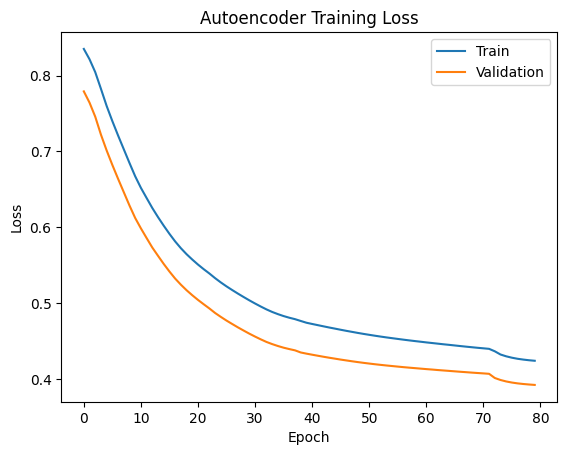

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Autoencoder Training Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.legend(["Train", "Validation"])
plt.show()

In [16]:
autoencoder.save("autoencoder.h5")